# Text Summarization — 01 Exploring the Data

**Extractive summarization**: pick the most important sentences from a news article. We use a 300-article sample of CNN/DailyMail, where each article has a human-written reference summary (the `highlights`). This notebook explores article vs summary lengths and the compression task.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils

df=utils.load_articles()
df['art_words']=df['article'].str.split().apply(len)
df['sum_words']=df['summary'].str.split().apply(len)
print('articles:',len(df))
print('article words  — median %d'%df['art_words'].median())
print('summary words  — median %d'%df['sum_words'].median())

articles: 300
article words  — median 428
summary words  — median 34


## 1. Length distributions & compression

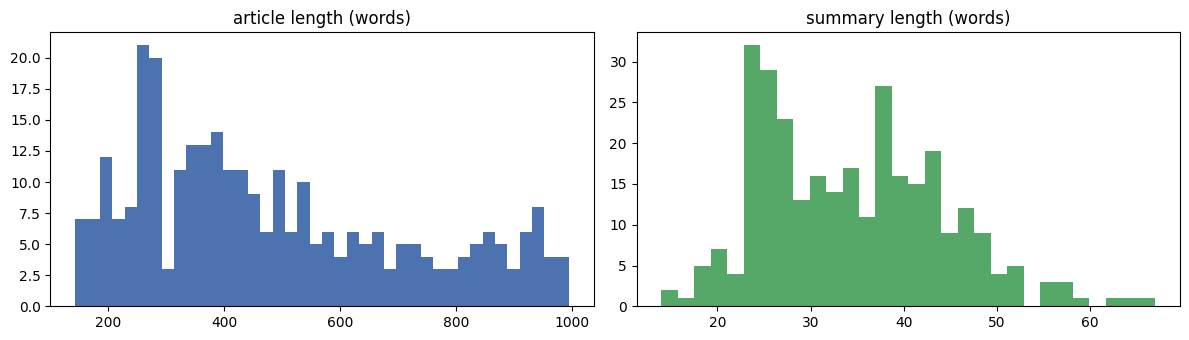

mean compression: summary is 7% of article length


In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['art_words'],bins=40,color='#4c72b0'); ax[0].set_title('article length (words)')
ax[1].hist(df['sum_words'],bins=30,color='#55a868'); ax[1].set_title('summary length (words)')
plt.tight_layout(); plt.show()
print('mean compression: summary is %.0f%% of article length'%(100*df['sum_words'].mean()/df['art_words'].mean()))

## 2. A sample article and its reference summary

In [3]:
ex=df.iloc[0]
print('ARTICLE (first 400 chars):\n',ex['article'][:400],'...')
print('\nREFERENCE SUMMARY:\n',ex['summary'])
print('\nsentences in article:',len(utils.split_sentences(ex['article'])))

ARTICLE (first 400 chars):
 (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

REFERENCE SUMMARY:
 Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

sentences in article: 27


## 3. Summary

- 300 articles, median ~**480 words** each, summarized to ~**34 words** (a ~7% compression).
- Reference summaries are abstractive (human-written); our extractive methods can only **select** sentences, so ROUGE will be bounded — but extractive is fast, unsupervised, and never hallucinates.
- Notebook 02 builds three summarizers; 03 scores them with ROUGE.